In [17]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 선형, 다항, 리지, 라쏘회귀, 교차검증

공부 시간(시간)과 시험 점수(점수) 간의 관계
* 실제로 학생들이 공부한 시간이 많을수록 점수가 높아지는 경향이 있지만, 
* 일정 시간 이상 공부하면 피로로 인해 성적이 떨어지는 
* 비선형적인 관계를 나타낸다고 가정합니다.

## 1. 데이터 생성

In [ ]:
np.random.seed(42)

X = np.linspace(1, 10, 100).reshape(-1, 1)   # 공부 시간 (1~10시간)
y = -0.5 * X**2 + 5 * X + 15 + np.random.randn(100, 1) * 1.2  # 시험 점수: 비선형 관계로 억지(?) 생성

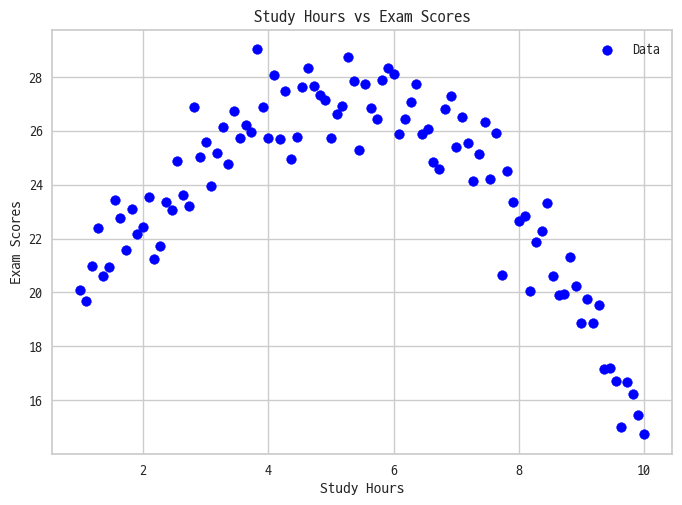

In [6]:
# 데이터 시각화
plt.scatter(X, y, color="blue", label="Data")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Study Hours vs Exam Scores")
plt.legend()
plt.show()

## 2. 단순 선형회귀

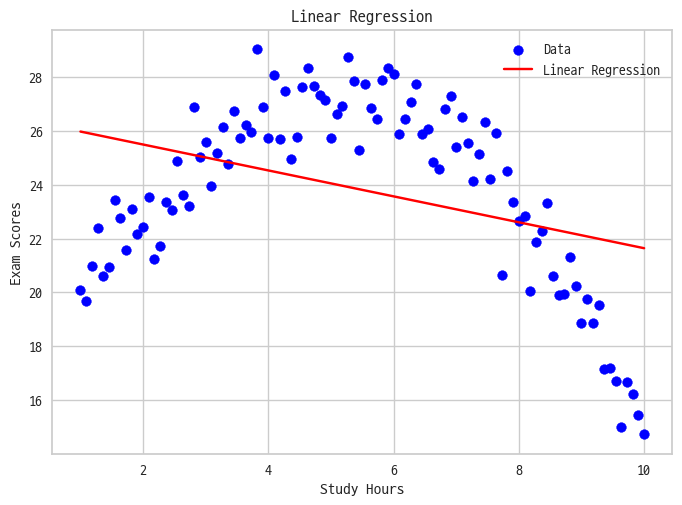

In [7]:
# 선형회귀 모델 생성 및 학습
linear_model = LinearRegression()
linear_model.fit(X, y)

# 예측
y_pred_linear = linear_model.predict(X)

# 결과 시각화
plt.scatter(X, y, color="blue", label="Data")
plt.plot(X, y_pred_linear, color="red", label="Linear Regression")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Linear Regression")
plt.legend()
plt.show()

## 3. 다항회귀

다항 회귀 결정계수 (R^2): 0.9013
다항 회귀 모델의 교차검증 R^2: [0.88303374 0.93456185 0.81780499 0.95884138 0.7664264 ]
다항 회귀 모델의 교차검증 평균 R^2: 0.8721
다항 회귀 모델의 교차검증 표준편차: 0.0716


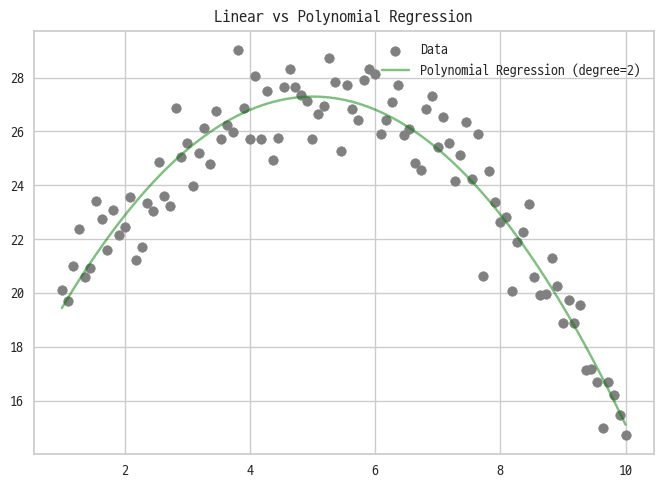

In [ ]:
# 다항 변환 (2차 다항식)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 표준화 
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# 다항 회귀 모델 학습 (변환 데이터 사용)
poly_reg = LinearRegression()
poly_reg.fit(X_poly_scaled, y)
y_pred_poly = poly_reg.predict(X_poly_scaled)

# 결정계수 (R^2)
r2_poly = poly_reg.score(X_poly_scaled, y)
print(f"다항 회귀 결정계수 (R^2): {r2_poly:.4f}")

# 교차검증을 통한 R^2 값 계산
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(poly_reg, X_poly_scaled, y, cv=kf, scoring='r2')

# 교차검증 결과 출력
print(f"다항 회귀 모델의 교차검증 R^2: {cv_scores}")
print(f"다항 회귀 모델의 교차검증 평균 R^2: {cv_scores.mean():.4f}")    # 0.7이상이면 좋은 모델
print(f"다항 회귀 모델의 교차검증 표준편차: {cv_scores.std():.4f}")     # 값이 작을 수록 좋다

# 시각화
plt.scatter(X, y, color='gray', label='Data')
plt.plot(X, y_pred_poly, color='green', label='Polynomial Regression (degree=2)', alpha=0.5)
plt.legend()
plt.title('Linear vs Polynomial Regression')
plt.show()

### 과대적합이 아니므로 여기서 다항회귀로 완료되어야 하나 혹시 과대적합이면 리지, 라쏘를 진행한다

## 4. 리지회귀

### 교차검증
* 다항 회귀 모델에 대해 교차검증(cross-validation)을 실시하여 모델 성능(R²)을 평가하는 과정
* R² 점수가 높고 표준편차가 작으면 안정적이고 좋은 모델

리지 회귀 모델의 결정계수 (R²): 0.8337
리지 회귀 모델의 교차검증 R^2: [0.75122787 0.80827135 0.78330291 0.81885654 0.7321057 ]
리지 회귀 모델의 교차검증 평균 R^2: 0.7788
리지 회귀 모델의 교차검증 표준편차: 0.0330


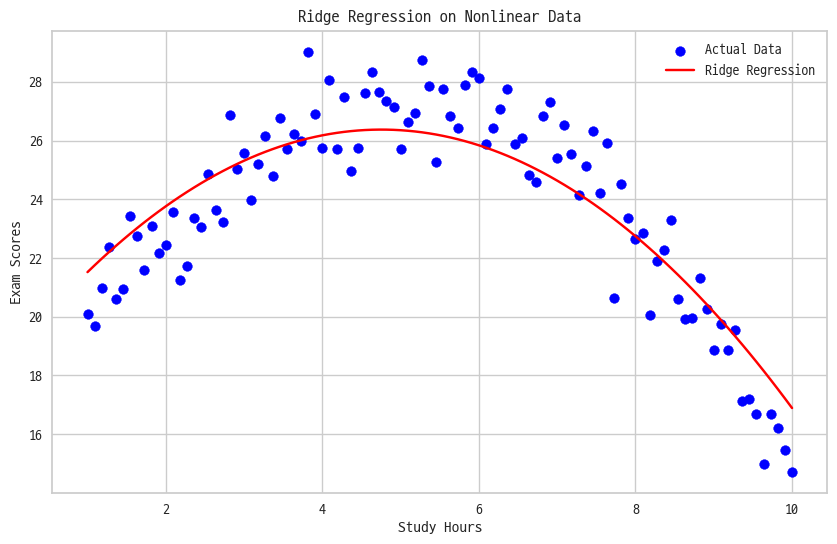

In [25]:
# 다항 특성 변환 (2차 다항식)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 데이터 표준화 
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)


# 리지 회귀 모델 학습
ridge = Ridge(alpha=1.0)
ridge.fit(X_poly_scaled, y)

# 예측
y_pred_ridge = ridge.predict(X_poly_scaled)

# 결정계수(R²) 계산
r2 = ridge.score(X_poly_scaled, y)  # 전체 데이터셋에 대한 R² 계산
print(f"리지 회귀 모델의 결정계수 (R²): {r2:.4f}")

# 교차검증을 통한 R^2 값 계산
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ridge, X_poly_scaled, y, cv=kf, scoring='r2')

# 교차검증 결과 출력
print(f"리지 회귀 모델의 교차검증 R^2: {cv_scores}")
print(f"리지 회귀 모델의 교차검증 평균 R^2: {cv_scores.mean():.4f}")
print(f"리지 회귀 모델의 교차검증 표준편차: {cv_scores.std():.4f}")

# 시각화
plt.figure(figsize=(10, 6))

# 실제 데이터 산점도
plt.scatter(X, y, color="blue", label="Actual Data")

# 리지 회귀 예측 값
X_range = np.linspace(1, 10, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
X_range_poly_scaled = scaler.transform(X_range_poly)  # 표준화
y_pred_ridge = ridge.predict(X_range_poly_scaled)
plt.plot(X_range, y_pred_ridge, color="red", label="Ridge Regression")

# 차트 설정
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Ridge Regression on Nonlinear Data")
plt.legend()
plt.show()

### 제미나이 제안 코드

전체 데이터셋에 대한 R²: 0.8337
교차검증 평균 R^2: 0.7790
교차검증 표준편차: 0.0324


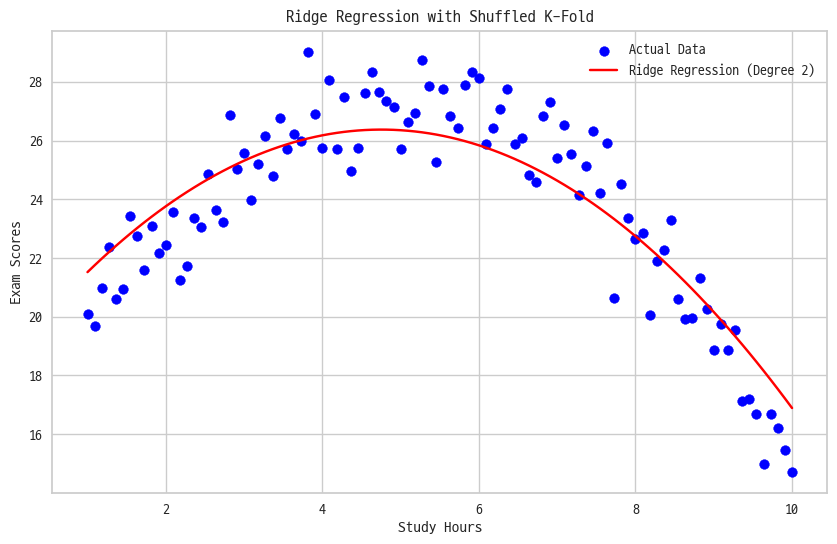

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline

# 1. 모델 구성 (Pipeline 활용 - 데이터 누수 방지 및 가독성 향상)
# 다항변환 -> 스케일링 -> 리지회귀를 하나로 묶습니다.
model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0)
)

# 2. 모델 학습 (전체 데이터)
model.fit(X, y)

# 3. 결정계수(R²) 계산
r2 = model.score(X, y)
print(f"전체 데이터셋에 대한 R²: {r2:.4f}")

# 4. 교차검증 설정 (shuffle=True 필수!)
# 데이터 순서에 의한 편향을 제거하기 위해 데이터를 섞습니다.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. 교차검증 수행
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print(f"교차검증 평균 R^2: {cv_scores.mean():.4f}")
print(f"교차검증 표준편차: {cv_scores.std():.4f}")

# 6. 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="Actual Data")

# 예측을 위한 부드러운 곡선 생성
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = model.predict(X_range)

plt.plot(X_range, y_range_pred, color="red", label="Ridge Regression (Degree 2)")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Ridge Regression with Shuffled K-Fold")
plt.legend()
plt.show()


## 5. 라쏘회귀

라쏘 회귀 모델의 결정계수 (R²): 0.8244
라쏘 회귀 모델의 교차검증 R^2: [0.77171686 0.82127737 0.79888061 0.82122179 0.74694163]
라쏘 회귀 모델의 교차검증 평균 R^2: 0.7920
라쏘 회귀 모델의 교차검증 표준편차: 0.0290


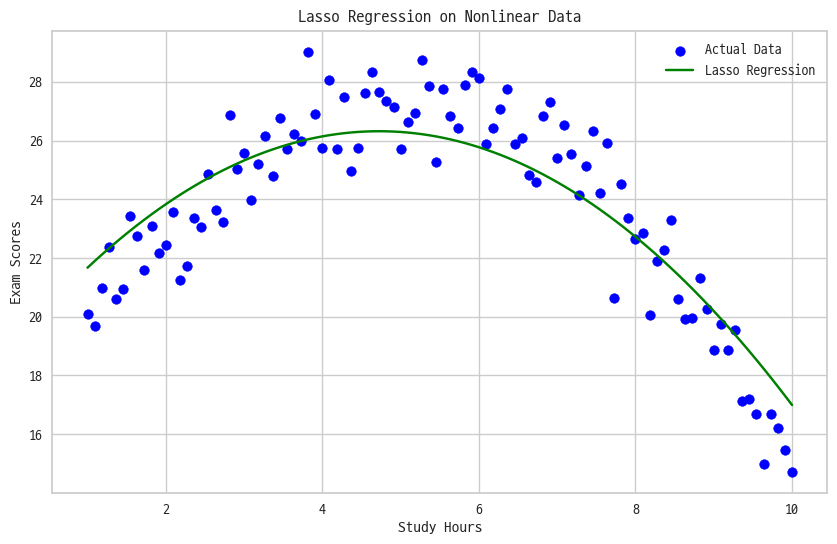

In [27]:
# 다항 특성 변환 (2차 다항식)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 데이터 표준화
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# 라쏘 회귀 모델 학습
lasso = Lasso(alpha=0.1)
lasso.fit(X_poly_scaled, y)

# 예측
y_pred_lasso = lasso.predict(X_poly_scaled)


# 결정계수(R²) 계산
r2 = lasso.score(X_poly_scaled, y)  # 전체 데이터셋에 대한 R² 계산
print(f"라쏘 회귀 모델의 결정계수 (R²): {r2:.4f}")

# 교차검증을 통한 R^2 값 계산
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lasso, X_poly_scaled, y, cv=kf, scoring='r2')

# 교차검증 결과 출력
print(f"라쏘 회귀 모델의 교차검증 R^2: {cv_scores}")
print(f"라쏘 회귀 모델의 교차검증 평균 R^2: {cv_scores.mean():.4f}")
print(f"라쏘 회귀 모델의 교차검증 표준편차: {cv_scores.std():.4f}")


# 시각화
plt.figure(figsize=(10, 6))

# 실제 데이터 산점도
plt.scatter(X, y, color="blue", label="Actual Data")

# 라쏘 회귀 예측 값
X_range = np.linspace(1, 10, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
X_range_poly_scaled = scaler.transform(X_range_poly)  # 표준화
y_pred_lasso = lasso.predict(X_range_poly_scaled)
plt.plot(X_range, y_pred_lasso, color="green", label="Lasso Regression")

# 차트 설정
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Lasso Regression on Nonlinear Data")
plt.legend()
plt.show()